<a href="https://colab.research.google.com/github/johnryantaylor/QCES/blob/main/Project2_transport.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2: Transport

A critical aspect of understanding climate and environmental systems is describing the movement of substances. This could include pollution or water vapor in the atmosphere, salt in an estuary, or chemicals in a river. We often model transport using an advection/diffusion equation.

In this project we will use Dedalus to solve for the transport of groundwater in a subsurface aquifer and to model the concentration of pollution in a river using the advection/diffusion equation.

Student tasks are in [Section 1.4](#section1pt4) and [Section 2.3](#section2pt3)

## Setup
If you are using Google colab, run the script below to install Dedalus

In [ ]:
# Set environment variables for best performance
%env OMP_NUM_THREADS=1
%env NUMEXPR_MAX_THREADS=1

# Minimize logging output
import logging
logging.disable(logging.DEBUG)

# Check if running on google colab
import os
using_google_colab = bool(os.getenv("COLAB_RELEASE_TAG"))

# Check for Dedalus
try:
    import dedalus.public as de
    print("Dedalus already installed :)")
except:
    print("Dedalus not installed yet.")
    if using_google_colab:
        print("Installing for Google Colab.")
        print()
        # Step 1: Install FFTW
        !apt-get install libfftw3-dev
        !apt-get install libfftw3-mpi-dev
        # Step 2: Set paths for Dedalus installation
        import os
        os.environ['MPI_INCLUDE_PATH'] = "/usr/lib/x86_64-linux-gnu/openmpi/include"
        os.environ['MPI_LIBRARY_PATH'] = "/usr/lib/x86_64-linux-gnu"
        os.environ['FFTW_INCLUDE_PATH'] = "/usr/include"
        os.environ['FFTW_LIBRARY_PATH'] = "/usr/lib/x86_64-linux-gnu"
        # Step 3: Install Dedalus using pip
        !pip3 install cython mpi4py numpy setuptools wheel
        !CC=mpicc pip3 install --no-cache --no-build-isolation http://github.com/dedalusproject/dedalus/zipball/master/
        !pip3 install -q ipympl
        # Step 4: Check installation
        print()
        try:
            import dedalus.public as de
            print("Dedalus successfully installed :)")
        except:
            print("Error installing Dedalus :(")
            raise
    else:
        print("See website for installation instructions:")
        print("https://dedalus-project.readthedocs.io/en/latest/pages/installation.html")

# Setup interactive matplotlib
if using_google_colab:
    from google.colab import output
    output.enable_custom_widget_manager()

## 1. Groundwater flow

The flow of water through a groundwater aquifer and the flow into a nearby river can be modeled by combining Darcy's law for the flow thorugh a porous medium with consevation of mass. This leads to a partial differential equation for the height of the water table, $h(x,t)$, where $x$ is the distance from the river and $t$ is time.


### 1.1 Theory

The theory for the flow through a groundwater aquifer is briefly summarized here. See the FEM lectures and notes for a full explanation. Consider two-dimensional flow of groundwater toward a river. Let $x$ be the distance from the river, $h(x,t)$ be the height of the water table, $\phi$ be the porosity of the aquifer, and $R(t)$ be the rainfall rate.

Darcy's law balances viscous resistance in the porous medium against pressure gradients (including buoyancy). For a long, thin aquifer the vertical velocity is small, so the pressure is approximately hydrostatic. The horizontal velocity in the aquifer is then

$$ u = -u_b \frac{\partial h}{\partial x}, $$

where $u_b= k\rho g/\mu$ is the buoyancy velocity, $k$ is the permeability, $\rho$ is the fluid density, $g$ is gravity, and $\mu$ is the dynamic viscosity.

The corresponding volume flux (per unit width) through a vertical section of the aquifer is

$$ q = \int_0^h u\,\mathrm{d}z = -u_b h \frac{\partial h}{\partial x}, $$

assuming that the buoyancy velocity is constant. Conservation of mass then gives an evolution equation for the height of the water table:

$$ \phi \frac{\partial h}{\partial t} - u_b \frac{\partial}{\partial x}\left(h\frac{\partial h}{\partial x}\right) = R. $$

The boundary conditions are $h=0$ at the river ($x=0$) and no flux through the drainage divide ($q=0$ at $x=L$). The volume flux into the river is

$$ Q_R = -q(x=0) = u_b h \frac{\partial h}{\partial x}\bigg|_{x=0}. $$



### 1.2 Model

The script below configures and runs Dedalus to solve for the height of the groundwater aquifer and the volume flux into the river. In this example, the rainfall rate is

$$ R(t) = \begin{cases} 0 & t < 0, \\ R_0 & 0 < t < T, \\ 0 & t > T, \end{cases} $$

where the rainfall rate is steady for a time $T$.

For simplicity, we will assume that the aquifer is empty before the rain so that 

$$ h(t=0) = 0. $$

Since the boundary conditions at $x=0$ and $x=L$ are not periodic, we solve the equation using a Chebyshev transform in the $x$ direction.

In [19]:
"""
Script to use Dedalus to solve for the height of the water table and the volume flux into the river
"""

import numpy as np
import matplotlib.pyplot as plt
import dedalus.public as dedalus
import logging
logger = logging.getLogger(__name__)

# For convenience, define 1 hour and 1 day
hour = 3600 # seconds
day = 24 * hour
kilometer = 1e3

# Set parameters
phi = 0.3 # porosity (non-dimensional)
k = 1e-10 # permeability, units: m^2
rho = 1000 # density of water in kg/m^3
g = 9.81 # gravitational acceleration (m/s^2)
mu = 1e-3 # dynamic viscosity of water in kg/(m*s)
ub = k * rho * g / mu # buoyancy velocity (m/s)
R0 = 5e-3 / day # rainfall rate (5 mm/day)
T = 60 * day # rainfall duration
L = 100 # length of the aquifer (m)

# Derived parameters
H = L*(R0/ub)**0.5 # water table height at steady state

# Numerical parameters
Nx = 64 # number of gridpoints in x
stop_sim_time = 120 * day # end time
timestep = 1 * hour # timestep
nu = ub * (R0/ub)**0.5 * L # implicit diffusivity based on the characteristic water table height

# Bases and coordinates
coords = dedalus.CartesianCoordinates('x')
dist = dedalus.Distributor(coords, dtype=np.float64)
xbasis = dedalus.ChebyshevT(coords['x'], size=Nx, bounds=(0, L), dealias=3/2)
x = dist.local_grid(xbasis)

# Fields
h = dist.Field(name='h', bases=xbasis)
tau_1 = dist.Field(name='tau_1')
tau_2 = dist.Field(name='tau_2')
R = dist.Field(name='R')
R['g'] = R0

# Substitutions
lift_basis = xbasis.derivative_basis(1)
lift = lambda A: dedalus.Lift(A, lift_basis, -1)
dx = lambda A: dedalus.Differentiate(A, coords['x'])
hx = dx(h) + lift(tau_1) # define the derivative of h(x)

# Problem
problem = dedalus.IVP([h, tau_1, tau_2], namespace=locals())
problem.add_equation("phi*dt(h) - nu*dx(hx) + lift(tau_2) = R + ub*dx(h*hx) - nu*dx(hx)")
problem.add_equation("h(x='left') = 0")
problem.add_equation("hx(x='right') = 0")

# Now, set the solver
solver = problem.build_solver(dedalus.RK222)
solver.stop_sim_time = stop_sim_time

# Initial condition: empty aquifer
h['g'] = 0

# Volume of water in the aquifer (per unit width)
volume = phi * dedalus.integ(h)

# River flux Q_R = ub * h * dh/dx evaluated at the river
QR = (ub * h * hx)(x='left')

# Create arrays to periodically save the water table height for plotting later
h.change_scales(1)
h_save = [np.copy(h['g'])];
t_save = [solver.sim_time]; # Save the initial condition and the initial time
volume_save = [np.copy(volume.evaluate()['g'])]
QR_save = [np.copy(QR.evaluate()['g'])]

# Specify the rainfall rate as a function of time
def rainfall_rate(t):
    return np.where((t >= 0) & (t < T), R0, 0.0)

# Main loop
try:
    logger.info('Starting main loop')
    while solver.proceed:
        R['g'] = rainfall_rate(solver.sim_time)
        solver.step(timestep)
        if (solver.iteration-1) % 10 == 0:
            logger.info('Iteration=%i, Time=%e days, dt=%e' %(solver.iteration, solver.sim_time/day, timestep))
            h.change_scales(1)
            h_save.append(np.copy(h['g']))
            t_save.append(solver.sim_time)
            volume_save.append(np.copy(volume.evaluate()['g']))
            QR_save.append(np.copy(QR.evaluate()['g']))
except:
    logger.error('Exception raised, triggering end of main loop.')
    raise
finally:
    solver.log_stats()

# Convert the variables to numpy arrays for allow array slicing
h_save = np.array(h_save)
t_save = np.array(t_save)
volume_save = np.array(volume_save).squeeze()
QR_save = np.array(QR_save).squeeze()


2026-10-07 11:14:02,594 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 3.4e+01/s


2026-10-07 11:14:02,631 __main__ 0/1 INFO :: Starting main loop
2026-10-07 11:14:02,636 __main__ 0/1 INFO :: Iteration=1, Time=4.166667e-02 days, dt=3.600000e+03
2026-10-07 11:14:02,658 __main__ 0/1 INFO :: Iteration=11, Time=4.583333e-01 days, dt=3.600000e+03
2026-10-07 11:14:02,679 __main__ 0/1 INFO :: Iteration=21, Time=8.750000e-01 days, dt=3.600000e+03
2026-10-07 11:14:02,704 __main__ 0/1 INFO :: Iteration=31, Time=1.291667e+00 days, dt=3.600000e+03
2026-10-07 11:14:02,724 __main__ 0/1 INFO :: Iteration=41, Time=1.708333e+00 days, dt=3.600000e+03
2026-10-07 11:14:02,742 __main__ 0/1 INFO :: Iteration=51, Time=2.125000e+00 days, dt=3.600000e+03
2026-10-07 11:14:02,759 __main__ 0/1 INFO :: Iteration=61, Time=2.541667e+00 days, dt=3.600000e+03
2026-10-07 11:14:02,777 __main__ 0/1 INFO :: Iteration=71, Time=2.958333e+00 days, dt=3.600000e+03
2026-10-07 11:14:02,796 __main__ 0/1 INFO :: Iteration=81, Time=3.375000e+00 days, dt=3.600000e+03
2026-10-07 11:14:02,813 __main__ 0/1 INFO :: I

## 1.3 Visualization

The script below plots the rainfall rate, the water table height, and the volume flux into the river.


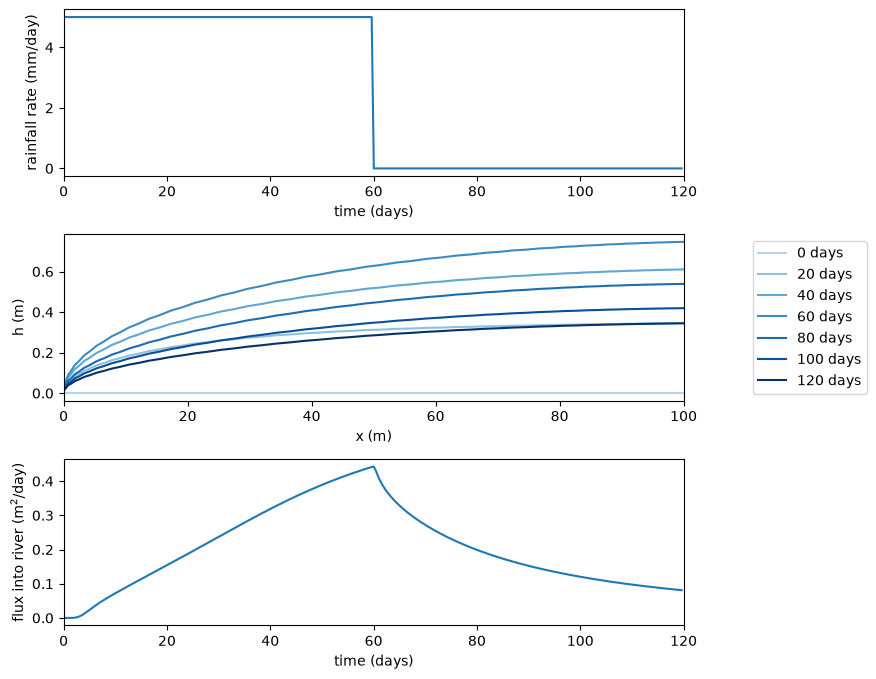

In [ ]:
# create a figure and axes
fig = plt.figure(figsize=(8,8))

# Plot the rainfall rate
plt.subplot(3,1,1)
plt.plot(t_save / day, rainfall_rate(t_save) * 1e3 * day)
# Specify the axis limits and labels
plt.xlim(0, stop_sim_time / day)
plt.xlabel('time (days)')
plt.ylabel('rainfall rate (mm/day)')

# Plot the water table height at 20-day intervals
plt.subplot(3,1,2)
times_to_plot = [0, 20, 40, 60, 80, 100, 120] # days to include in plot
colors = plt.cm.Blues(np.linspace(0.3, 1.0, len(times_to_plot)))
x_plot = np.squeeze(x)
for i, t_plot in enumerate(times_to_plot):
    n = np.argmin(np.abs(t_save - t_plot * day))
    plt.plot(x_plot, np.squeeze(h_save[n]), color=colors[i], label='{0} days'.format(t_plot))
# Specify the axis limits and labels
plt.xlim(0, L)
plt.xlabel('x (m)')
plt.ylabel('h (m)')
plt.legend(loc='center left', bbox_to_anchor=(1.1, 0.5)) # add legend to the right of the plot

# Plot the flux into the river
plt.subplot(3,1,3)
plt.plot(t_save / day, QR_save * day)
# Specify the axis limits and labels
plt.xlim(0, stop_sim_time / day)
plt.xlabel('time (days)')
plt.ylabel('flux into river (m$^2$/day)')

plt.subplots_adjust(hspace=0.35) # add space between the panels


## 1.4 Student investigation
<a id='section1pt4'></a>
### Analytical comparison
In Fundamentals of Environmental Modelling we derived expressions for the flux into the river at early and late times. Compare these predictions with the simulation output and discuss any differences along with possible sources of error (~1 figure and ~3-4 sentences).

### Qualitative behaviour
Explore different functional forms for the rainfall rate and the properties of the reservoir (e.g. size and permeability).  Include 2-3 figures to show the resutls of your parameter exploration and add 1-2 pargraphs to discuss and interpret your results.

## 2. Transport of pollution in a river

Advection/diffusion equations are a common way to model the material transport in many physical systems. In this section we will model the transport and dilution of a pollutants added to a river.

For simplicity, we will model the river as a rectangular channel, and we will neglect depth variations. Let $x$ be the coordinate along the length of the river, and $y$ be the cross-stream coordinate. We will model the river current as 

$$ u(y) = U_0\left(1-\frac{(y-w/2)^2}{(w/2)^2}\right) $$

where $w$ is the width of the river and $U_0$ is the maximum current speed which occurs at the center of the river (the $y$-coordinate will run from 0 to $w$).

Since we want to know how the pollution levels vary in time, we will solve the time-dependent advection/diffusion equation. We will model the addition of pollution by adding a spatially-dependent source term to the right hand side of the equation governing pollutant concentration:

$$ \frac{\partial c}{\partial t} + u(y)\frac{\partial c}{\partial x} = \kappa \nabla^2 c + S(x,y) $$

where $\nabla^2=(\partial_x^2 + \partial_y^2)$ is the Laplacian operator for diffusion in 2D Cartesian coordinates, and $S$ is the source term.

### 2.1 Dedalus script

The script below solves the time-dependent advection/diffusion equation with a source term.

In [ ]:
"""
Script to solve the time-dependent advection/diffusion equation
"""

import numpy as np
import matplotlib.pyplot as plt
import dedalus.public as dedalus
import logging
logger = logging.getLogger(__name__)

# Set parameters
U0 = 0.1 # maximum current speed in m/s
w = 10 # width of the river in m
L = 50 # length of the river section to simulate
kappa = 1e-2 # diffusivity in m^2/s
S0 = 1 # amplitude of the pollution source term
S_w = 1 # width of the source term in m
S_x = 10 # center of the forcing in x
S_y = 0 # center of the forcing in y
S_t = 1 # forcing timescale

# Numerical parameters
Nx = 256 # number of gridoints in x
Ny = 32 # number of gridpoints in y
stop_sim_time=1500 # end time in seconds
timestep = (L/Nx)/U0 # timestep in seconds, calculated from the CFL number

import numpy as np
import dedalus.public as dedalus
import logging
logger = logging.getLogger(__name__)

# Bases and coordinates
coords = dedalus.CartesianCoordinates('x', 'y')
dist = dedalus.Distributor(coords, dtype=np.float64)
xbasis = dedalus.RealFourier(coords['x'], size=Nx, bounds=(0, L), dealias=3/2)
ybasis = dedalus.ChebyshevT(coords['y'], size=Ny, bounds=(0, w), dealias=3/2)
x, y = dist.local_grids(xbasis, ybasis)
ex, ey = coords.unit_vector_fields(dist) # x and y unit vectors

# Fields
c = dist.Field(name='c', bases=(xbasis,ybasis))
u = dist.Field(name='u', bases=(xbasis,ybasis))
tau_1 = dist.Field(name='tau_1', bases=xbasis)
tau_2 = dist.Field(name='tau_2', bases=xbasis)

# Specify the velocity field
u['g'] = U0 * (1- (y - w/2)**2.0/(w/2)**2.0) # parabolic velocity profile

# Substitutions
lift_basis = ybasis.derivative_basis(1)
lift = lambda A: dedalus.Lift(A, lift_basis, -1)
grad_c = dedalus.grad(c) + ey*lift(tau_1)
dx = lambda A: dedalus.Differentiate(A, coords['x'])

S = dist.Field(name='u', bases=(xbasis,ybasis))
S['g'] = S0*np.exp(-(x-S_x)**2.0/S_w**2.0-(y-S_y)**2.0/S_w**2.0)

# Problem
problem = dedalus.IVP([c, tau_1, tau_2], namespace=locals())
problem.add_equation("dt(c) + u*dx(c) - kappa*div(grad_c) + lift(tau_2) = S/S_t")
problem.add_equation("c(y=0) = 0")
problem.add_equation("c(y=w) = 0")

# Now, set the solver
solver = problem.build_solver(dedalus.RK222)
solver.stop_sim_time = stop_sim_time

# Create an array to periodically save the concentration field for plotting later
c.change_scales(1)
c_save = [np.copy(c['g'])]; 

t_save = [solver.sim_time]; # Save the initial condition and the initial time
# Main loop
try:
    logger.info('Starting main loop')
    while solver.proceed:
        solver.step(timestep)
        if (solver.iteration-1) % 10 == 0:
            logger.info('Iteration=%i, Time=%e, dt=%e' %(solver.iteration, solver.sim_time, timestep))
            c.change_scales(1)
            c_save.append(np.copy(c['g']))
            t_save.append(solver.sim_time)
except:
    logger.error('Exception raised, triggering end of main loop.')
    raise
finally:
    solver.log_stats()

# Convert the variables to numpy arrays for allow array slicing
c_save = np.array(c_save)

## 2.2 Visualization

The script below makes a movie of the results from the saved variables. To run this, you need to have ffmpeg installed.  If you don't already have it installed, you can install ffmpeg with the command: 

`conda install -c conda-forge ffmpeg`

In [ ]:
# create a figure and axes
fig = plt.figure(figsize=(6,6))

# Create arrays with the latitude and longitude coordinates for plotting using pcolor
from dedalus.extras import plot_tools
(X, Y) = plot_tools.quad_mesh(np.squeeze(x), np.squeeze(y))  

# Define an animation function
def drawframe(n):
    plt.clf()
    concentration = plt.pcolor(X, Y, c_save[n,:,:].T)
    # Specify the axis limits and labels
    plt.axis('square')
    plt.xlim(0, L)   
    plt.ylim(0, w)  
    plt.xlabel('x (m)')
    plt.ylabel('y (m)')
    plt.title('concentration, time = {0:.2f} seconds'.format(t_save[n]))
    return (concentration,)

from matplotlib import animation
# blit=True re-draws only the parts that have changed.
anim = animation.FuncAnimation(fig, drawframe, frames=len(t_save), interval=40, blit=True)

from IPython.display import HTML
HTML(anim.to_html5_video())

## 2.3 Student investigation
<a id='section2pt3'></a>
### Advective/diffusive timescales
In the boxes below, plot the pollution concentration at a few points as a function of time. Then vary the maximum flow speed and the diffusivity and explore how the pollution levels depend on these parameters. Using dimensional analysis, estimate the time needed for the pollution to reach the opposite side of the river. How far downstream of the source do you expect this to happen (assuming that the domain in the x-direction is infinite).

In [ ]:
# ADD YOUR CODE HERE

ADD DISCUSSION HERE

### Turbulent diffusion
In a turbulent flow, tracers will be transported by the turbulent eddies. A common way to model this is to introduce a turbulent diffusivity, $\kappa_T\sim u*l$, where $u$ and $l$ are characteristic velocity and length scales associated with the turbulent eddies.

To explore this effect, create a Dedalus script that includes advection by $u$ and $v$ (the $x$ and $y$ components of the velocity). Then, use the same velocity field as above for $u$ and add to that a fluctuating velocity field that of the form

$$ u=u_0 cos(kx)cos(ky), \quad v=u_0 sin(kx)sin(ky) $$

where $k$ is the wavenumber associated with the velocity fluctuations and $u_0$ is the amplitude of the fluctuations. Note that $k$ should be set to give an integer number of wavelengths in the $x$ and $y$ directions. Vary both $u_0$ and $k$ and study how quicky the tracer is transported across the river. Qualitatively compare this with the expectation based on the hypothesis of turbulent diffusion.

INSERT PLOTS AND COMMENTS HERE

## 3. Optional further investigations

* In the river pollution example, you might notice that the concentration field is mixed more effectively in the x-direction than in the y-direction. The combination of differential advection by the currents and cross-stream diffusion is very effective at mixing the plume in the x-direction. This is an example of Taylor dispersion (Taylor, 1953). Construct numerical experiments to quantify Taylor dispersion and its dependence on the current shear and the diffusivity. You could also separate the diffusivity into parts in the x and y directions with different coefficients.  If you set the x-component of the diffusivity to zero, then any spreading of the concentration in the x-direction should be due to Taylor dispersion.

* Try making the river speed a function of time. The easiest way to do this is to add a new equation so that Dedalus solves for the velocity in addition to the concentration field. For example, you could make the river speed decrease exponentially in time, or it could be sinusoidal in time.

* In the ocean mixing example, if $\kappa$ is a function of $x$ and $z$, what would this imply about the velocity field? You could even try writing a Dedalus script to solve the 2D advection/diffusion equation with a prescribed spatially-dependent $\kappa(x,z)$.


### References

Munk, W.H., 1966. Abyssal recipes. In Deep sea research and oceanographic abstracts (Vol. 13, No. 4, pp. 707-730). Elsevier.

Ferrari, R., Mashayek, A., McDougall, T.J., Nikurashin, M. and Campin, J.M., 2016. Turning ocean mixing upside down. Journal of Physical Oceanography, 46(7), pp.2239-2261.

Taylor, G.I., 1953. Dispersion of soluble matter in solvent flowing slowly through a tube. Proceedings of the Royal Society of London. Series A. Mathematical and Physical Sciences, 219(1137), pp.186-203.